
# Método de Bisección

## Ejemplo 1 de Burden

**Objetivo:** implementar en Python el **Algoritmo 2.1: Bisección** y comprobarlo con el Ejemplo 1 de la página 38 del libro de Burden.

> **Nota:** El texto de Burden utiliza, para este ejemplo, un criterio de paro basado en una **cota del error relativo**. Por ello se muestran tanto el algoritmo de bisección como la comprobación del criterio utilizado en el ejemplo.



## 1. Planteamiento del problema

Se desea aproximar una raíz de

\[
f(x)=x^3+4x^2-10
\]

en el intervalo

\[
[a,b]=[1,2].
\]

Primero comprobamos que el intervalo es adecuado para bisección:

\[
f(1)=-5,\qquad f(2)=14.
\]

Como

\[
f(1)f(2)<0,
\]

y \(f\) es continua (es un polinomio), por el **Teorema del Valor Intermedio** existe al menos una raíz en \([1,2]\).



## 2. Método de bisección

En cada iteración se calcula el punto medio

\[
p=a+\frac{b-a}{2}.
\]

Después se evalúa \(f(p)\). Si \(f(a)\) y \(f(p)\) tienen el mismo signo, la nueva pareja de extremos es

\[
[a,b]=[p,b].
\]

En caso contrario, se toma

\[
[a,b]=[a,p].
\]

Así, el intervalo que contiene la raíz se reduce a la mitad en cada iteración.

### Criterio del Algoritmo 2.1

El algoritmo de Burden detiene el proceso cuando

\[
f(p)=0
\]

o cuando

\[
\frac{b-a}{2}<TOL.
\]

También se establece un número máximo de iteraciones para evitar un ciclo indefinido.



## 3. Librerías

Se utilizan:

- `pandas` para organizar las iteraciones en una tabla.
- `matplotlib.pyplot` para realizar las gráficas.
- `math` para operaciones numéricas sencillas.

`import` permite cargar una librería y utilizar sus funciones dentro del programa.


In [1]:
import math
import pandas as pd
import matplotlib.pyplot as plt



## 4. Definición de la función

En Python, `def` permite definir una función. El operador `**` representa una potencia; por ejemplo, `x**3` significa \(x^3\).


In [2]:
def f(x):
    # Función del Ejemplo 1 de Burden
    return x**3 + 4*x**2 - 10

# Comprobación de los extremos del intervalo
print("f(1) =", f(1))
print("f(2) =", f(2))


f(1) = -5
f(2) = 14



## 5. Implementación del Algoritmo 2.1

La siguiente función sigue los pasos del algoritmo de Burden:

1. Se inicia con \(a\), \(b\) y \(FA=f(a)\).
2. Se calcula el punto medio \(p\).
3. Se calcula \(FP=f(p)\).
4. Se revisa el criterio de paro.
5. Se actualiza el extremo que tiene el mismo signo que \(FP\).
6. Se guarda la información de cada iteración.

La variable `datos` permite conservar los resultados para mostrarlos posteriormente en una tabla.


In [3]:
def biseccion(a, b, tol, nmax):
    """Algoritmo 2.1 de Burden: método de bisección."""

    i = 1
    fa = f(a)
    datos = []

    while i <= nmax:
        # Paso 3: calcular el punto medio
        p = a + (b - a) / 2
        fp = f(p)

        # Paso 4: criterio de paro del Algoritmo 2.1
        if fp == 0 or (b - a) / 2 < tol:
            datos.append([i, a, b, p, fa, fp, (b - a) / 2])
            return p, datos, True

        # Paso 5 y 6: seleccionar el nuevo intervalo
        if fa * fp > 0:
            a = p
            fa = fp
        else:
            b = p

        datos.append([i, a, b, p, fa, fp, (b - a) / 2])
        i += 1

    return p, datos, False



## 6. Prueba del Algoritmo 2.1

Usamos los datos del ejemplo:

\[
a=1,\qquad b=2,\qquad TOL=10^{-4}.
\]

El valor `nmax = 100` funciona como límite de seguridad para el número de iteraciones.


In [4]:
a0 = 1
b0 = 2
tol = 10**(-4)
nmax = 100

raiz_alg, datos_alg, exito = biseccion(a0, b0, tol, nmax)

if exito:
    print(f"Raíz aproximada: {raiz_alg:.10f}")
    print(f"Iteraciones: {len(datos_alg)}")
else:
    print("El método alcanzó el número máximo de iteraciones.")


Raíz aproximada: 1.3651733398
Iteraciones: 14



### Tabla de iteraciones del Algoritmo 2.1


In [5]:
tabla_alg = pd.DataFrame(
    datos_alg,
    columns=["i", "a", "b", "p", "f(a)", "f(p)", "Cota del error"]
)

tabla_alg


,i,a,b,p,f(a),f(p),Cota del error
0,1,1.000000,1.500000,1.500000,-5.000000,2.375000,0.250000
1,2,1.250000,1.500000,1.250000,-1.796875,-1.796875,0.125000
2,3,1.250000,1.375000,1.375000,-1.796875,0.162109,0.062500
3,4,1.312500,1.375000,1.312500,-0.848389,-0.848389,0.031250
4,5,1.343750,1.375000,1.343750,-0.350983,-0.350983,0.015625
5,6,1.359375,1.375000,1.359375,-0.096409,-0.096409,0.007812
6,7,1.359375,1.367188,1.367188,-0.096409,0.032356,0.003906
7,8,1.363281,1.367188,1.363281,-0.032150,-0.032150,0.001953
8,9,1.363281,1.365234,1.365234,-0.032150,0.000072,0.000977
9,10,1.364258,1.365234,1.364258,-0.016047,-0.016047,0.000488



## 7. Reproducción del criterio de paro del Ejemplo 1 de Burden

En la página 38, Burden continúa el ejemplo hasta \(p_{13}\) y utiliza una **cota del error relativo**:

\[
\frac{|p-p_N|}{\min\{|a_N|,|b_N|\}}<10^{-4}.
\]

La idea es que, después de actualizar el intervalo, la longitud del intervalo proporciona una cota para el error de la aproximación.

Para reproducir exactamente el resultado mostrado en el libro, se detiene el proceso cuando

\[
\frac{|b-a|}{\min\{|a|,|b|\}}<10^{-4}.
\]


In [6]:
def biseccion_ejemplo_burden(a, b, tol, nmax):
    """Bisección usando la cota de error relativo mostrada
    en el Ejemplo 1 de Burden.
    """

    fa = f(a)
    datos = []

    for i in range(1, nmax + 1):
        # Punto medio
        p = a + (b - a) / 2
        fp = f(p)

        # Actualización del intervalo que contiene la raíz
        if fa * fp > 0:
            a = p
            fa = fp
        else:
            b = p

        # Cota del error relativo indicada por Burden
        cota_relativa = abs(b - a) / min(abs(a), abs(b))

        datos.append([i, a, b, p, fp, cota_relativa])

        if fp == 0 or cota_relativa < tol:
            return p, datos, True

    return p, datos, False


In [7]:
raiz_burden, datos_burden, exito_burden = biseccion_ejemplo_burden(
    1, 2, 10**(-4), 100
)

tabla_burden = pd.DataFrame(
    datos_burden,
    columns=["i", "a", "b", "p", "f(p)", "Cota error relativo"]
)

tabla_burden


,i,a,b,p,f(p),Cota error relativo
0,1,1.000000,1.500000,1.500000,2.375000,0.500000
1,2,1.250000,1.500000,1.250000,-1.796875,0.200000
2,3,1.250000,1.375000,1.375000,0.162109,0.100000
3,4,1.312500,1.375000,1.312500,-0.848389,0.047619
4,5,1.343750,1.375000,1.343750,-0.350983,0.023256
5,6,1.359375,1.375000,1.359375,-0.096409,0.011494
6,7,1.359375,1.367188,1.367188,0.032356,0.005747
7,8,1.363281,1.367188,1.363281,-0.032150,0.002865
8,9,1.363281,1.365234,1.365234,0.000072,0.001433
9,10,1.364258,1.365234,1.364258,-0.016047,0.000716



## 8. Resultado del Ejemplo 1

El método produce

\[
\boxed{p_{13}=1.3651123046875}
\]

que coincide con el valor mostrado por Burden, salvo por el redondeo de las cifras.

Para la iteración 13,

\[
\frac{|b_{14}-a_{14}|}{\min\{|a_{14}|,|b_{14}|\}}
\approx 8.94\times10^{-5}<10^{-4}.
\]

Por lo tanto, se cumple el criterio de paro usado en el ejemplo.


In [8]:
print(f"Solución aproximada: p_13 = {raiz_burden:.10f}")
print(f"f(p_13) = {f(raiz_burden):.10f}")
print(f"Cota del error relativo = {datos_burden[-1][-1]:.10e}")


Solución aproximada: p_13 = 1.3651123047
f(p_13) = -0.0019436590
Cota del error relativo = 8.9421443262e-05



## 9. Gráficas

La primera gráfica muestra la función y la aproximación de la raíz. La segunda muestra cómo los puntos medios se acercan a la solución durante las iteraciones.


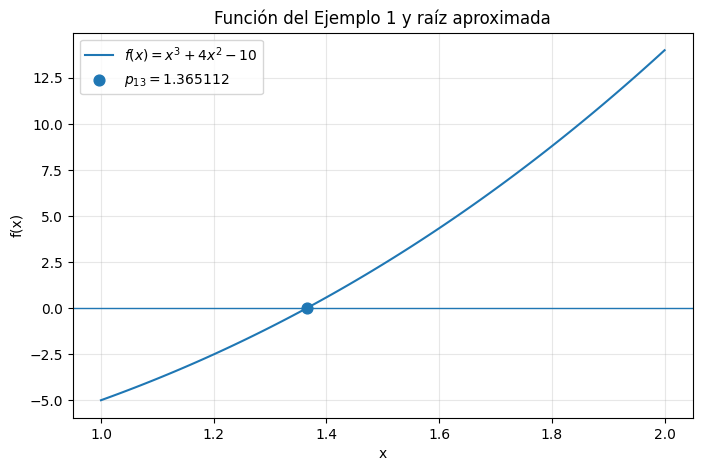

In [9]:
# Gráfica de la función y de la raíz aproximada
x = [1 + 0.01*i for i in range(101)]
y = [f(valor) for valor in x]

plt.figure(figsize=(8, 5))
plt.plot(x, y, label=r"$f(x)=x^3+4x^2-10$")
plt.axhline(0, linewidth=1)
plt.scatter([raiz_burden], [f(raiz_burden)], s=60,
            label=fr"$p_{{13}}={raiz_burden:.6f}$")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Función del Ejemplo 1 y raíz aproximada")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


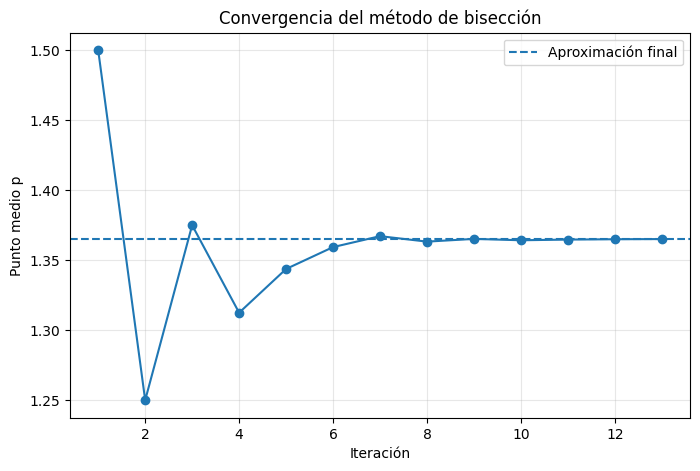

In [10]:
# Convergencia de los puntos medios
iteraciones = [fila[0] for fila in datos_burden]
puntos_medios = [fila[3] for fila in datos_burden]

plt.figure(figsize=(8, 5))
plt.plot(iteraciones, puntos_medios, marker="o")
plt.axhline(raiz_burden, linestyle="--",
            label="Aproximación final")

plt.xlabel("Iteración")
plt.ylabel("Punto medio p")
plt.title("Convergencia del método de bisección")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()



## 10. Conclusión

El método de bisección permite encontrar una aproximación a una raíz cuando la función es continua y los valores en los extremos del intervalo tienen signos opuestos.

Para

\[
f(x)=x^3+4x^2-10,\qquad [a,b]=[1,2],
\]

se obtiene, siguiendo el criterio de error relativo utilizado en el Ejemplo 1 de Burden,

\[
\boxed{\mathbf{p_{13}=1.3651123046875}}
\]

y se verifica que la cota del error relativo es menor que \(10^{-4}\).

**Observación importante:** si se utiliza estrictamente el criterio de paro del Algoritmo 2.1,

\[
\frac{b-a}{2}<10^{-4},
\]

el resultado puede aparecer en una iteración posterior. Esto no significa que la bisección esté mal; se debe a que el ejemplo de la página 38 usa un criterio de error relativo diferente.
